In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(62017)

n = 10
lr = 0.1
n_steps = 100
snapshots = [1, 2, 5, 10, 25, 100]

# For the learning-rate comparison figure: fewer iterations so that
# lambda=1.0 (which interpolates after 10 iterations) and lambda=0.5 don't
# both collapse on top of each other.
n_steps_compare = 20
lr_values = [0.01, 0.1, 0.5, 1.0]

In [2]:
x = np.arange(0.5, n + 0.5)
y = x + 2.0 * rng.normal(size=n)

# Dense x-grid for plotting the piecewise-constant fit: 100 points per bin.
xx = np.linspace(0.01, n, 100 * n)
def step_curve(f):
    return np.repeat(f, 100)

x_line = np.array([0.0, n])
y_line = x_line

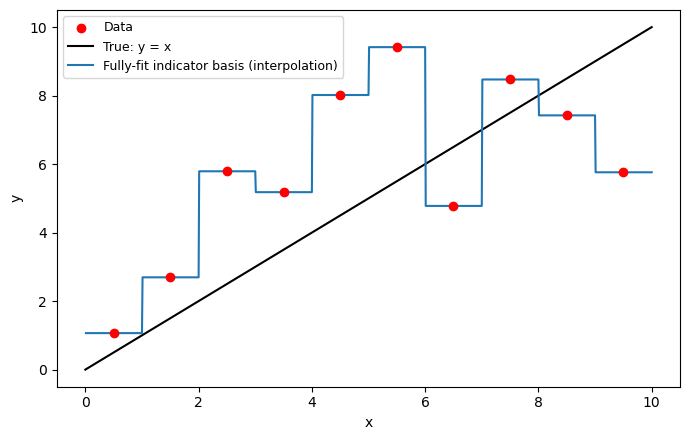

In [3]:
# Baseline: fully-grown basis fit = interpolation at every observation.
# Each D[:, j] = 1{i == j}, so the OLS projection returns y exactly.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x, y, color="red", zorder=3, label="Data")
ax.plot(x_line, y_line, color="black", lw=1.5, label="True: y = x")
ax.plot(xx, step_curve(y), color="tab:blue", lw=1.5,
        label="Fully-fit indicator basis (interpolation)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [4]:
# Boosting on the 10 one-hot indicators with learning rate lr.
# Each step: find the observation with the largest residual (argmin SSE after
# that indicator is subtracted), shrink its prediction by lr * resid.
f = np.full(n, y.mean())
history = [f.copy()]
for _ in range(n_steps):
    resid = y - f
    j = int(np.argmax(np.abs(resid)))
    f[j] += lr * resid[j]
    history.append(f.copy())

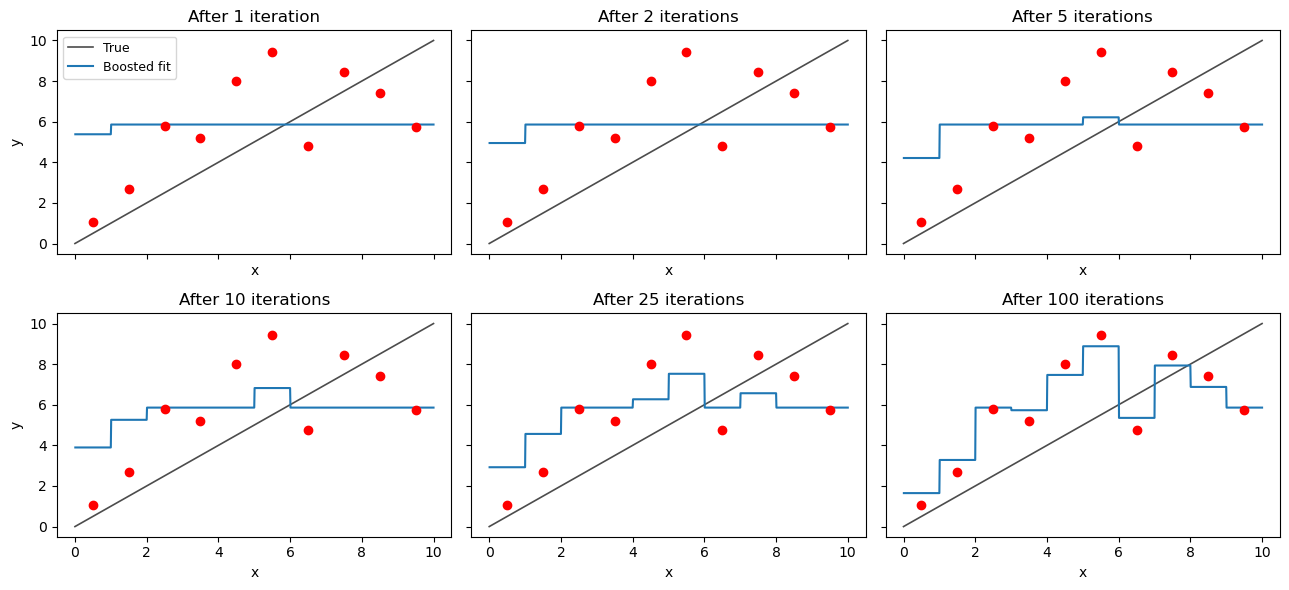

In [5]:
# Snapshots of the boosted fit at a handful of iterations.
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True, sharey=True)
for ax, s in zip(axes.ravel(), snapshots):
    ax.scatter(x, y, color="red", zorder=3)
    ax.plot(x_line, y_line, color="black", lw=1.2, alpha=0.7, label="True")
    ax.plot(xx, step_curve(history[s]), color="tab:blue", lw=1.5,
            label=f"Boosted fit")
    ax.set_title(f"After {s} iteration{'s' if s != 1 else ''}")
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("y")
axes[0, 0].legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

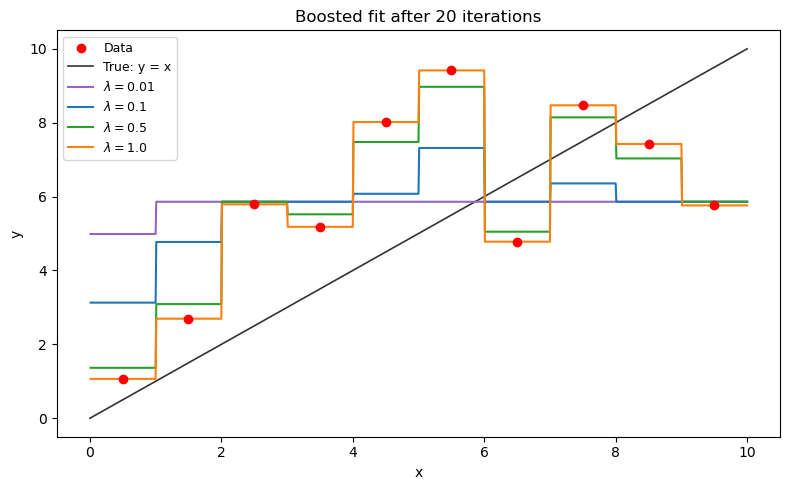

In [6]:
# Same boosting procedure, different learning rates, run for n_steps_compare
# iterations. Small lambda stays near the smooth signal; larger lambda pulls
# the fit aggressively toward the data (and, once lambda is large enough,
# interpolates the noise).
colors_lr = ["tab:purple", "tab:blue", "tab:green", "tab:orange"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color="red", zorder=3, label="Data")
ax.plot(x_line, y_line, color="black", lw=1.2, alpha=0.8, label="True: y = x")
for lrv, c in zip(lr_values, colors_lr):
    f_lr = np.full(n, y.mean())
    for _ in range(n_steps_compare):
        resid = y - f_lr
        j = int(np.argmax(np.abs(resid)))
        f_lr[j] += lrv * resid[j]
    ax.plot(xx, step_curve(f_lr), color=c, lw=1.5,
            label=fr"$\lambda = {lrv}$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Boosted fit after {n_steps_compare} iterations")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()